In [3]:
import numpy as np

# Colonnes: [Outlook, Temp, Humidity, Wind]
# Outlook: Sunny=0, Overcast=1, Rain=2
# Temp: Hot=0, Mild=1, Cool=2
# Humidity: High=0, Normal=1
# Wind: Weak=0, Strong=1
X = np.array([
    [0, 0, 0, 0], # Sunny, Hot, High, Weak
    [0, 0, 0, 1], # Sunny, Hot, High, Strong
    [1, 0, 0, 0], # Overcast, Hot, High, Weak
    [2, 1, 0, 0], # Rain, Mild, High , Weak
    [2, 2, 1, 0], #Rain, Cool, Normal, Weak
    [2, 2, 1, 1], #Rain, Cool, Normal, Strong
    [1, 2, 1, 1], #Overcast, Cool, Normal, Strong 
    [0, 1, 0, 0], #Sunny, Mild, High, Weak 
    [0, 2, 1, 0], #Sunny, Cool, Normal, Weak
    [2, 1, 1, 0], #Rain, Mild, Normal, Weak
    [0, 1, 1, 1], #Sunny, Mild, Normal, Strong
    [1, 1, 0, 1], #Overcast, Mild, High, Strong
    [1, 0, 1, 0], #Overcast, Hoy, Normal, Weak
    [2, 1, 0, 1] #Rain, Mild, High, Strong
])

class DBSCAN_Scratch:
    def __init__(self, eps, min_samples):
        self.eps = eps # Distance maximale pour être voisins
        self.min_samples = min_samples # Nombre min de voisins pour être un "Core Point"

    def fit(self, X):
        # -1 = Non visité, 0, 1, 2... = Cluster ID, -2 = Bruit (Noise)
        self.labels = np.full(X.shape[0], -1)
        cluster_id = 0

        for i in range(X.shape[0]):
            if self.labels[i] != -1: continue # Déjà traité

            # ÉTAPE 1 : Trouver les voisins
            neighbors = self._get_neighbors(X, i)

            # ÉTAPE 2 : Vérifier si c'est un point central (Core Point)
            if len(neighbors) < self.min_samples:
                self.labels[i] = -2 # Marqué comme bruit provisoirement
            else:
                # ÉTAPE 3 : Étendre le cluster
                self._expand_cluster(X, i, neighbors, cluster_id)
                cluster_id += 1
        return self.labels

    def _get_neighbors(self, X, point_idx):
        # Calcule la distance euclidienne entre le point et tous les autres
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, root_idx, neighbors, cluster_id):
        self.labels[root_idx] = cluster_id
        
        # On utilise une file (queue) pour visiter tous les voisins des voisins
        seeds = list(neighbors)
        for seed_idx in seeds:
            if self.labels[seed_idx] == -2: # Si c'était du bruit, ça devient une bordure
                self.labels[seed_idx] = cluster_id
            if self.labels[seed_idx] != -1: continue # Déjà traité

            self.labels[seed_idx] = cluster_id
            new_neighbors = self._get_neighbors(X, seed_idx)
            
            if len(new_neighbors) >= self.min_samples:
                seeds.extend(new_neighbors) # On ajoute les voisins du voisin à la liste

# --- TEST ---
model = DBSCAN_Scratch(eps=1.5, min_samples=2)
labels = model.fit(X)
print("Labels des points :", labels)

Labels des points : [0 0 0 0 0 0 0 0 0 0 0 0 0 0]


C:\Users\TECHNOMETIS\AppData\Local\Temp\ipykernel_55076\3351037387.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_labels))


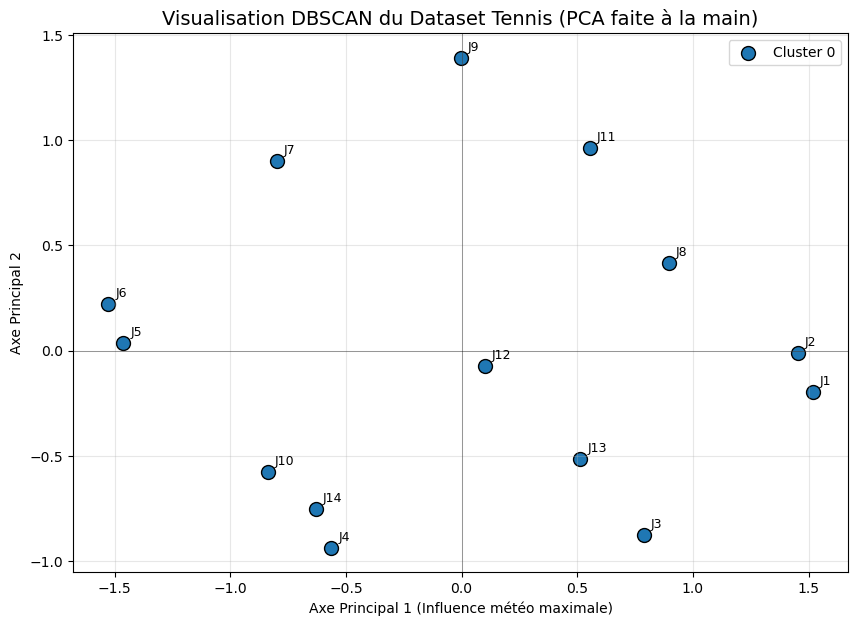

In [9]:
############################# ---------l'utilisation de PCA pour faire une réduction de dimension ---- ####

import numpy as np
import matplotlib.pyplot as plt

def manual_pca(X, n_components=2):
    # ÉTAPE 1 : Centrer les données (soustraire la moyenne)
    X_centered = X - np.mean(X, axis=0)
    
    # ÉTAPE 2 : Calculer la matrice de covariance
    # Elle mesure comment les variables (Outlook, Temp, etc.) évoluent ensemble
    cov_matrix = np.cov(X_centered.T)
    
    # ÉTAPE 3 : Calculer les vecteurs propres (eigenvectors) et valeurs propres
    # Les vecteurs propres définissent les nouvelles directions (axes) du graphe
    values, vectors = np.linalg.eigh(cov_matrix)
    
    # ÉTAPE 4 : Trier les vecteurs par importance (valeurs propres décroissantes)
    idx = np.argsort(values)[::-1]
    vectors = vectors[:, idx]
    
    # ÉTAPE 5 : Projeter les données sur les 2 meilleurs axes
    top_vectors = vectors[:, :n_components]
    return np.dot(X_centered, top_vectors)

# --- 1. Préparation des données et PCA ---
# On utilise la fonction de réduction de dimension qu'on vient de coder
X_2D = manual_pca(X, n_components=2)

# --- 2. Création du Graphe ---
plt.figure(figsize=(10, 7))

# Liste des couleurs pour les clusters
# On gère le bruit (label -2) à part en noir
unique_labels = np.unique(labels)
colors = plt.cm.get_cmap('viridis', len(unique_labels))

for i, label in enumerate(unique_labels):
    # Sélection des points appartenant au cluster actuel
    mask = (labels == label)
    points = X_2D[mask]
    
    if label == -2:
        # Couleur noire pour le bruit
        plt.scatter(points[:, 0], points[:, 1], c='black', s=100, label='Bruit (Outliers)', edgecolors='white')
    else:
        plt.scatter(points[:, 0], points[:, 1], s=100, label=f'Cluster {label}', edgecolors='k')

# --- 3. Ajout des détails d'explication ---
plt.title("Visualisation DBSCAN du Dataset Tennis (PCA faite à la main)", fontsize=14)
plt.xlabel("Axe Principal 1 (Influence météo maximale)")
plt.ylabel("Axe Principal 2")

# On ajoute les étiquettes J1, J2... pour identifier les jours
for i in range(len(X)):
    plt.annotate(f"J{i+1}", (X_2D[i, 0], X_2D[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.legend()
plt.grid(alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5) # Ligne horizontale centrale
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5) # Ligne verticale centrale
plt.show()

In [8]:
################################# sans aucune réduction de dimension  #####################


import numpy as np
# --- 1. LE DATASET TENNIS (Numérique) ---
# Outlook: Sunny=0, Overcast=1, Rain=2
# Temp: Hot=0, Mild=1, Cool=2
# Humidity: High=0, Normal=1
# Wind: Weak=0, Strong=1
X = np.array([
    [0, 0, 0, 0], # J1
    [0, 0, 0, 1], # J2
    [1, 0, 0, 0], # J3
    [2, 1, 0, 0], # J4
    [2, 2, 1, 0], # J5
    [2, 2, 1, 1], # J6
    [1, 2, 1, 1], # J7
    [0, 1, 0, 0], # J8
    [0, 2, 1, 0], # J9
    [2, 1, 1, 0], # J10
    [0, 1, 1, 1], # J11
    [1, 1, 0, 1], # J12
    [1, 0, 1, 0], # J13
    [2, 1, 0, 1]  # J14
])

# Noms des jours pour l'affichage final
jours = [f"Jour {i+1}" for i in range(len(X))]

# --- 2. L'ALGORITHME DBSCAN (From Scratch) ---
class DBSCAN_Scratch:
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples

    def fit(self, X):
        # -1 = Non visité, -2 = Bruit, 0,1,2... = Cluster ID
        self.labels = np.full(X.shape[0], -1)
        cluster_id = 0

        for i in range(X.shape[0]):
            if self.labels[i] != -1: continue # Déjà traité

            # ÉTAPE 1 : Trouver les voisins (en 4D !)
            neighbors = self._get_neighbors(X, i)

            # ÉTAPE 2 : Vérifier si c'est un point central
            if len(neighbors) < self.min_samples:
                self.labels[i] = -2 # Bruit provisoire
            else:
                # ÉTAPE 3 : Étendre le cluster
                self._expand_cluster(X, i, neighbors, cluster_id)
                cluster_id += 1
        return self.labels

    def _get_neighbors(self, X, point_idx):
        # Calcule la distance euclidienne en utilisant les 4 dimensions
        # C'est ici que les 4 colonnes météo sont utilisées
        distances = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(distances <= self.eps)[0]

    def _expand_cluster(self, X, root_idx, neighbors, cluster_id):
        self.labels[root_idx] = cluster_id
        seeds = list(neighbors)
        
        for seed_idx in seeds:
            if self.labels[seed_idx] == -2:
                self.labels[seed_idx] = cluster_id
            if self.labels[seed_idx] != -1: continue

            self.labels[seed_idx] = cluster_id
            new_neighbors = self._get_neighbors(X, seed_idx)
            if len(new_neighbors) >= self.min_samples:
                seeds.extend(new_neighbors)

# --- 3. EXÉCUTION ET AFFICHAGE DES RÉSULTATS ---

# Choix des paramètres (Eps=1.5 est un bon compromis pour ce petit dataset)
model = DBSCAN_Scratch(eps=1.5, min_samples=2)
labels = model.fit(X)

# Affichage propre des résultats
print("-" * 30)
print(f"{'Jour':<10} | {'Cluster ID':<12}")
print("-" * 30)

for i in range(len(jours)):
    label_text = ""
    if labels[i] == -2:
        label_text = "Bruit (Anomalie)"
    else:
        label_text = f"Cluster {labels[i]}"
        
    print(f"{jours[i]:<10} | {label_text}")

print("-" * 30)

# --- 4. ANALYSE SIMPLE DES RÉSULTATS ---
n_clusters = len(set(labels)) - (1 if -2 in labels else 0)
n_noise = list(labels).count(-2)

print(f"Nombre de clusters trouvés : {n_clusters}")
print(f"Nombre de jours considérés comme bruit : {n_noise}")

------------------------------
Jour       | Cluster ID  
------------------------------
Jour 1     | Cluster 0
Jour 2     | Cluster 0
Jour 3     | Cluster 0
Jour 4     | Cluster 0
Jour 5     | Cluster 0
Jour 6     | Cluster 0
Jour 7     | Cluster 0
Jour 8     | Cluster 0
Jour 9     | Cluster 0
Jour 10    | Cluster 0
Jour 11    | Cluster 0
Jour 12    | Cluster 0
Jour 13    | Cluster 0
Jour 14    | Cluster 0
------------------------------
Nombre de clusters trouvés : 1
Nombre de jours considérés comme bruit : 0
